C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13836\2422043429.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13836\2422043429.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13836\2422043429.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ip

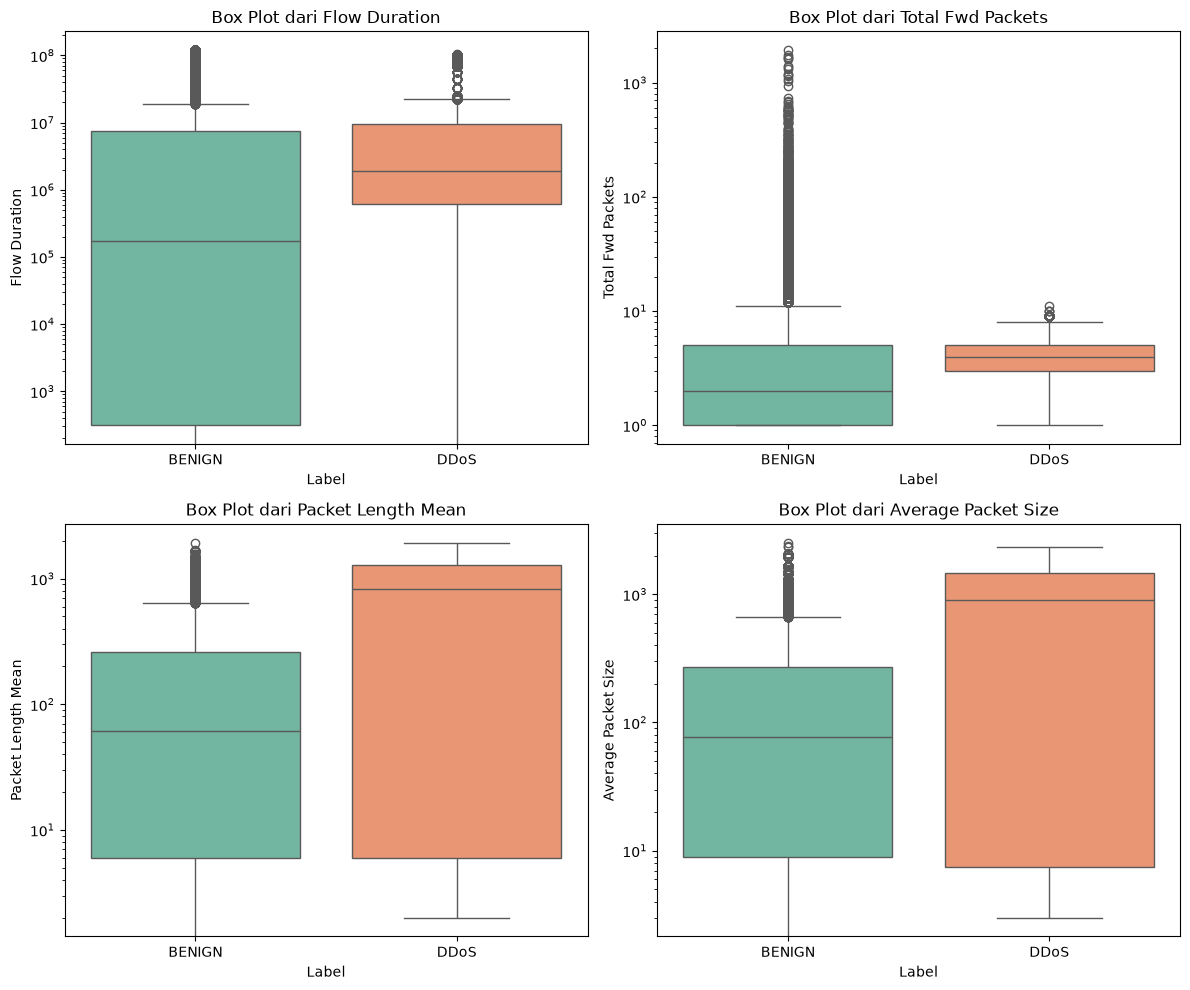

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset/Train_data.csv')
df.columns = df.columns.str.strip()

selected_cols = ['Flow Duration', 'Total Fwd Packets', 'Packet Length Mean', 'Average Packet Size']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.boxplot(x='Label', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Box Plot dari {col}', fontsize=12)
    # Menggunakan skala logaritmik karena rentang nilai traffic jaringan sangat lebar
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()

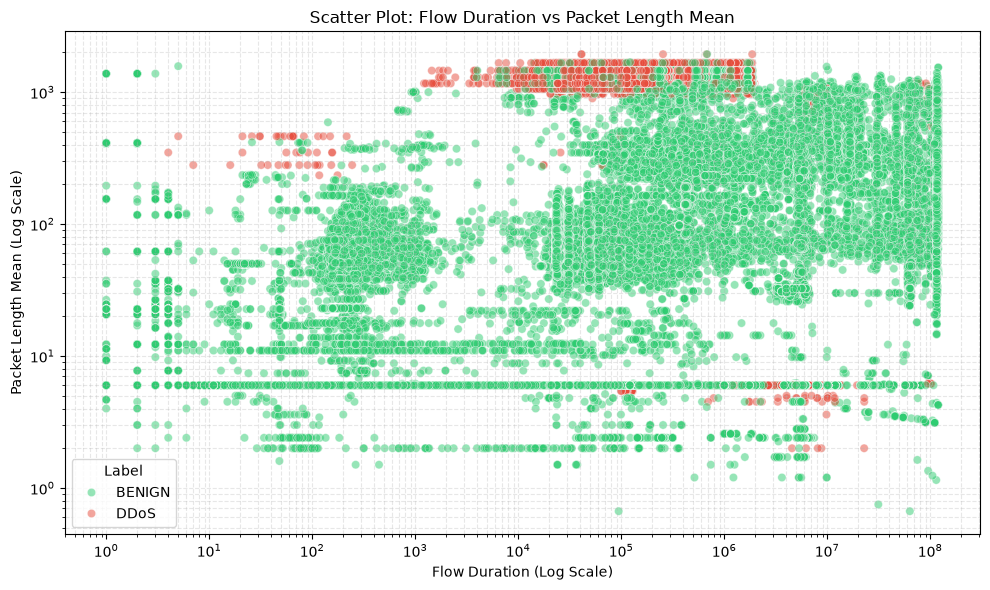

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset/Train_data.csv')
df.columns = df.columns.str.strip()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Flow Duration', 
    y='Packet Length Mean', 
    hue='Label', 
    alpha=0.5,
    palette={'BENIGN': '#2ecc71', 'DDoS': '#e74c3c'}
)

plt.xscale('log')
plt.yscale('log')

plt.title('Scatter Plot: Flow Duration vs Packet Length Mean', fontsize=12)
plt.xlabel('Flow Duration (Log Scale)')
plt.ylabel('Packet Length Mean (Log Scale)')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

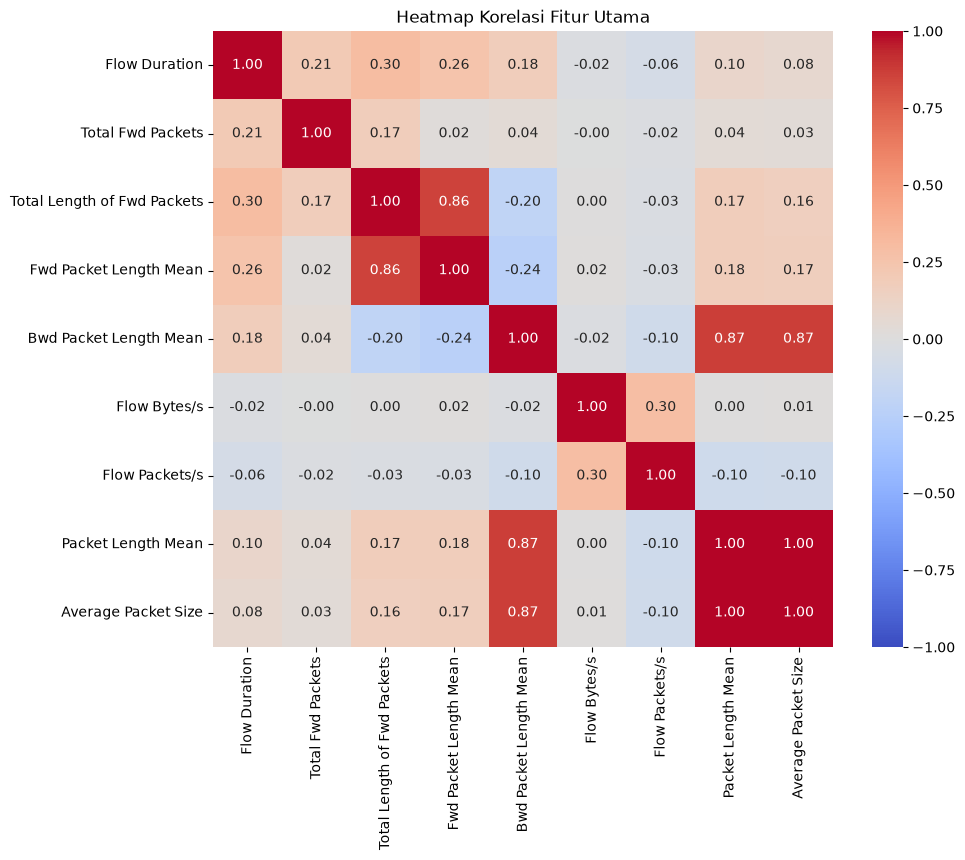

In [10]:
plt.figure(figsize=(10, 8))
cols = ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 
        'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 
        'Flow Packets/s', 'Packet Length Mean', 'Average Packet Size']

sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur Utama')
plt.show()

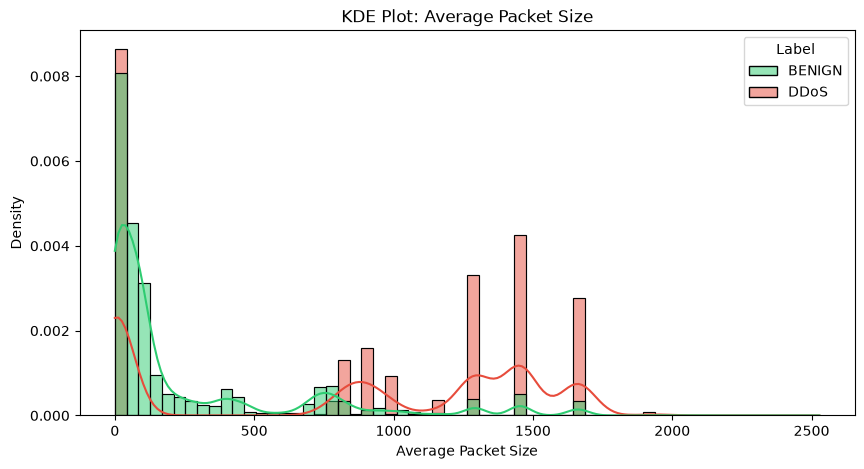

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Average Packet Size', hue='Label', kde=True, 
             stat="density", common_norm=False, palette={'BENIGN': '#2ecc71', 'DDoS': '#e74c3c'})
plt.title('KDE Plot: Average Packet Size')
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13836\2405854700.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Label', palette={'BENIGN': '#2ecc71', 'DDoS': '#e74c3c'})


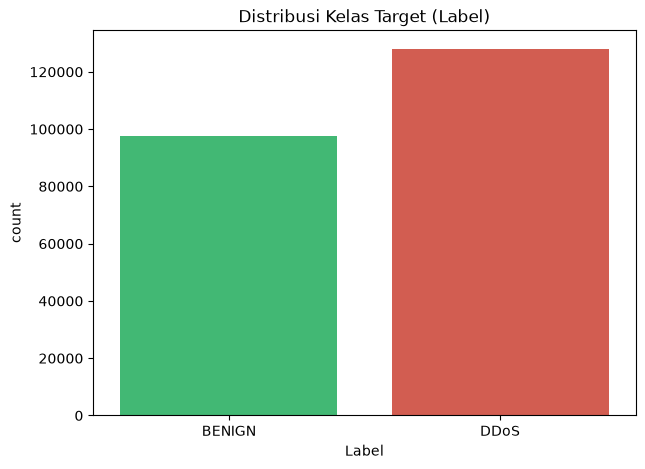

In [12]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Label', palette={'BENIGN': '#2ecc71', 'DDoS': '#e74c3c'})
plt.title('Distribusi Kelas Target (Label)')
plt.show()

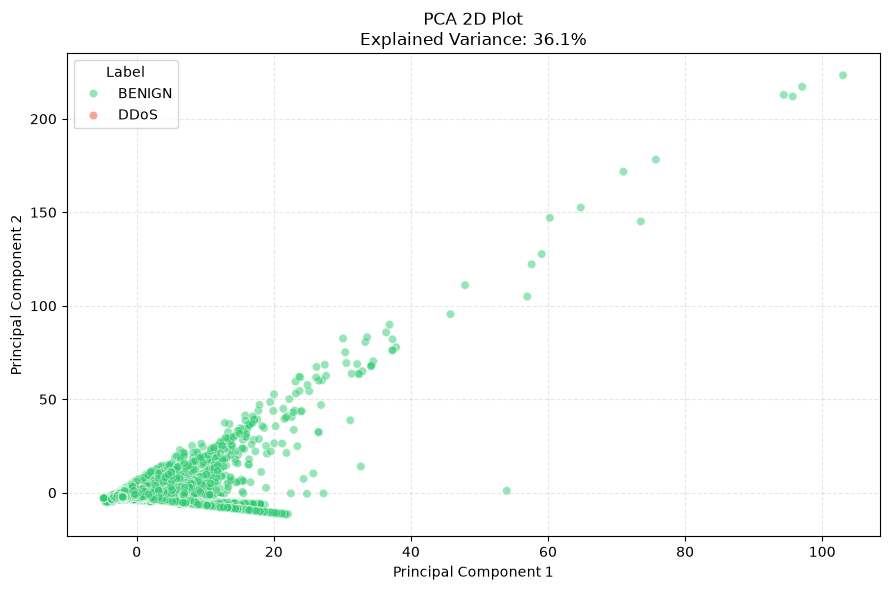

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('dataset/Train_data.csv')
df.columns = df.columns.str.strip()

num_cols = df.select_dtypes(include=['float64', 'int64']).copy()
num_cols = num_cols.replace([np.inf, -np.inf], np.nan)
num_cols = num_cols.fillna(num_cols.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(num_cols)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=df['Label'], 
    alpha=0.5, 
    palette={'BENIGN': '#2ecc71', 'DDoS': '#e74c3c'}
)
plt.title(f'PCA 2D Plot\nExplained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%', fontsize=12)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()